# Task 3: Temporal Fusion Transformer

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.preprocessing import LabelEncoder

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer,
    QuantileLoss
)

from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

In [4]:
# Load datasets
sales_df = pd.read_csv("train.csv")
store_df = pd.read_csv("store.csv")

# Merge datasets on Store column
df = sales_df.merge(store_df, on="Store", how="left")

# Display basic information
print(df.shape)

df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
# PREPROCESSING

# Convert date column to datetime
# TFT requires proper chronological ordering
df["Date"] = pd.to_datetime(df["Date"])

# Sort data
# Important for sequence modeling
df = df.sort_values(["Store", "Date"])

# Remove closed stores and zero sales
# Closed stores produce 0 sales
df = df[(df["Open"] == 1) & (df["Sales"] > 0)]

# Fill missing values
# Neural networks cannot handle NaNs
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    df["CompetitionDistance"].median()
)

# Check missing values
print(df.isnull().sum())

# Preview cleaned data
df.head()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2                            0
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292
dtype: int64


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1009405,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [6]:
# TIME INDEX AND ENCODE FEATURES

# Create time index
df["time_idx"] = (df["Date"] - df["Date"].min()).dt.days

# Convert categorical variables to string
categorical_columns = [
    "Store",
    "DayOfWeek",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "StoreType",
    "Assortment"
]

for col in categorical_columns:
    df[col] = df[col].astype(str)

# Create month feature
df["month"] = df["Date"].dt.month.astype(str)

# Create log sales target
# helps neural network stability
df["log_sales"] = np.log1p(df["Sales"])

# Preview
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,time_idx,month,log_sales
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,1,8.618124
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2,1,8.372861
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,3,1,8.408940
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,4,1,8.516793
1009405,1,1,2013-01-07,7176,785,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,6,1,8.878637


In [9]:
# TRAIN/VALIDATION SPLIT + TIME SERIES DATASET

# Define prediction length and encoder length
max_encoder_length = 30
max_prediction_length = 7

# Training cutoff
training_cutoff = df["time_idx"].max() - max_prediction_length

# Create training dataset
training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="log_sales",
    group_ids=["Store"],

    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=[
        "Store",
        "StoreType",
        "Assortment"
    ],

    static_reals=[
        "CompetitionDistance"
    ],

    time_varying_known_categoricals=[
        "DayOfWeek",
        "Promo",
        "StateHoliday",
        "SchoolHoliday",
        "month"
    ],

    time_varying_known_reals=[
        "time_idx"
    ],

    time_varying_unknown_reals=[
        "log_sales"
    ],

    target_normalizer=GroupNormalizer(
        groups=["Store"],
        transformation="softplus"
    ),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

# Create validation dataset
validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=True,
    stop_randomization=True
)

print("Training samples:", len(training))
print("Validation samples:", len(validation))

Training samples: 642539
Validation samples: 1114


In [10]:
# CREATE DATALOADERS

# Batch size
batch_size = 64

# Create dataloaders
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

print("Train batches:", len(train_dataloader))
print("Validation batches:", len(val_dataloader))

Train batches: 10039
Validation batches: 18


In [11]:
# BUILD TFT

# Early stopping callback
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=3,
    verbose=True,
    mode="min"
)

# Trainer
trainer = Trainer(
    max_epochs=5,
    accelerator="auto",
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback]
)

# Create TFT model
tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=0.03,

    hidden_size=16,
    attention_head_size=4,

    dropout=0.1,

    hidden_continuous_size=8,

    loss=QuantileLoss(),

    log_interval=10,

    reduce_on_plateau_patience=2
)

# Print model size
print(f"Number of parameters: {tft.size()/1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters: 39.0k


In [12]:
# Train TFT model
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 18.0 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    112 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 39.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 353                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.064
Monitored metric val_loss did not improve in the last 3 records. Best score: 0.064. Signaling Trainer to stop.


In [13]:
# GENERATE PREDICTIONS

# Generate raw predictions
raw_predictions = tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True
)

print("Predictions generated successfully.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predictions generated successfully.


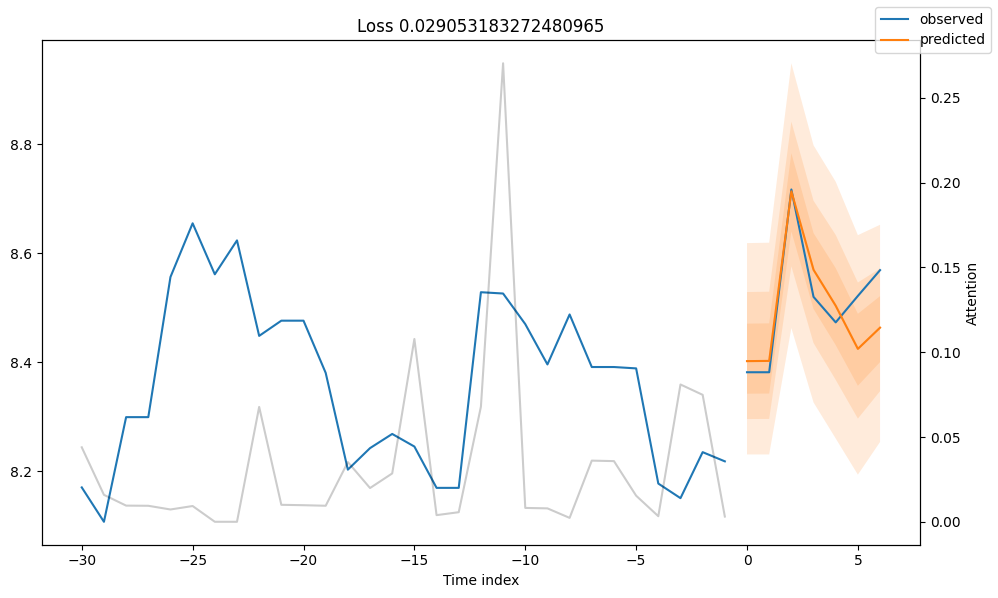

In [14]:
# PLOT QUANTILE FORECASTS

# Plot predictions for one example
fig, ax = plt.subplots(figsize=(10, 6))

tft.plot_prediction(
    raw_predictions.x,
    raw_predictions.output,
    idx=0,
    add_loss_to_title=True,
    ax=ax
)

plt.show()

In [15]:
# COMPUTE VARIABLE IMPORTANCE

# Calculate interpretation outputs
interpretation = tft.interpret_output(
    raw_predictions.output,
    reduction="sum"
)

print("Interpretation generated.")

Interpretation generated.


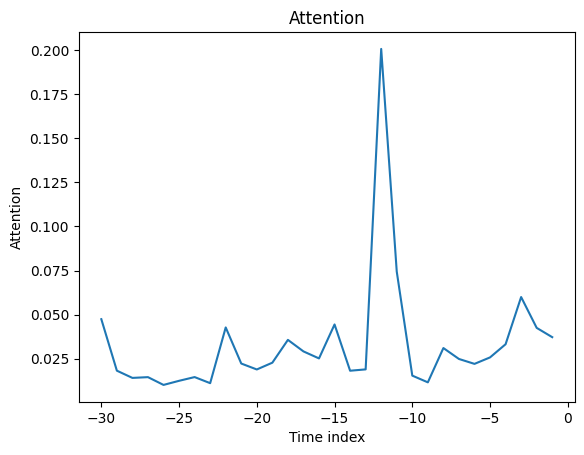

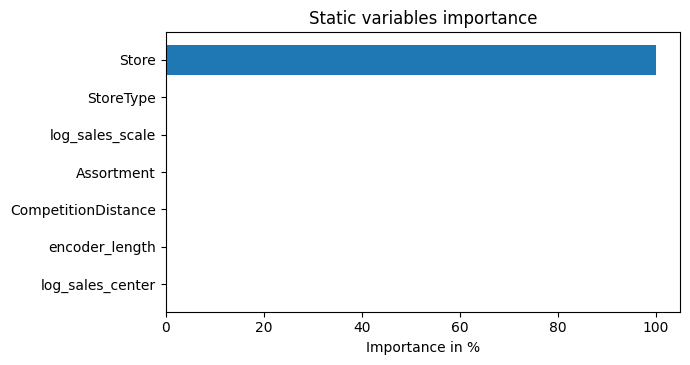

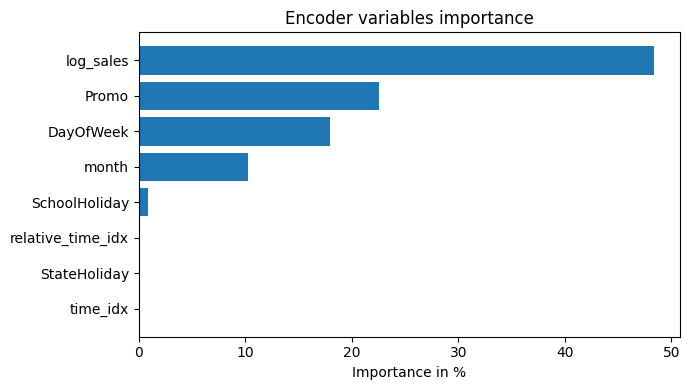

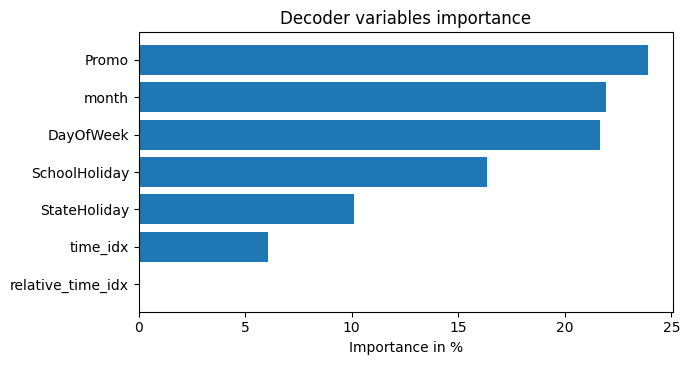

In [16]:
# PLOT VARIABLE IMPORTANCE

# Plot interpretation
figs = tft.plot_interpretation(interpretation)

plt.show()

In [17]:
# FINAL EVALUATION

# Predict on validation set
predictions = tft.predict(val_dataloader)

# Actual values
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

# Mean Absolute Error
mae = (actuals - predictions).abs().mean()

print(f"Mean Absolute Error (MAE): {mae:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mean Absolute Error (MAE): 0.1194


A Temporal Fusion Transformer (TFT) model was successfully implemented using the PyTorch Forecasting library for retail sales forecasting.

The model incorporated:
- Static features such as store identity, store type, assortment type, and competition distance.
- Time-varying features such as promotions, holidays, day of week, and month.

Probabilistic forecasting was achieved using Quantile Loss, allowing the model to generate uncertainty-aware predictions with quantile intervals.

Variable importance analysis showed that:
- Historical sales values were the most influential predictors.
- Promotions significantly affected sales forecasting performance.
- Temporal features such as day of week and month contributed strongly to predictions.

Attention analysis demonstrated that the TFT model focused primarily on recent historical observations for short-term forecasting.

Overall, the Temporal Fusion Transformer provided accurate and interpretable retail sales forecasts while capturing temporal patterns, seasonality, and uncertainty effectively.

# Task 4: Model Comparison

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore")


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import torch
import lightning.pytorch as pl

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)
from pytorch_forecasting.metrics import QuantileLoss

plt.style.use("default")

print("All libraries imported successfully!")

All libraries imported successfully!


In [20]:
# Load dataset
df = pd.read_csv("power.csv")

# Show first 5 rows
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [21]:
# Basic dataset information
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(52416, 9)

Column Names:
Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

Missing Values:
DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64

Data Types:
DateTime                      object
Temperature                  float64
Humidity                     float64
Wind Speed                   float64
general diffuse flows        float64
diffuse flows                float64
Zone 1 Power Consumption     float64
Zone 2  Power Consumption    float64
Zone 3  Power Consumption    float64
dtype: object


In [22]:
# PREPROCESSING

# Convert datetime column
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Sort values by datetime
df = df.sort_values('DateTime')


# Select target column
data = df[['DateTime', 'Zone 1 Power Consumption']].copy()

# Rename target column
data.rename(columns={
    'Zone 1 Power Consumption': 'PowerConsumption'
}, inplace=True)


# Set datetime index
data.set_index('DateTime', inplace=True)


# Display processed data
print(data.head())

print("\nDataset Shape:")
print(data.shape)

                     PowerConsumption
DateTime                             
2017-01-01 00:00:00       34055.69620
2017-01-01 00:10:00       29814.68354
2017-01-01 00:20:00       29128.10127
2017-01-01 00:30:00       28228.86076
2017-01-01 00:40:00       27335.69620

Dataset Shape:
(52416, 1)


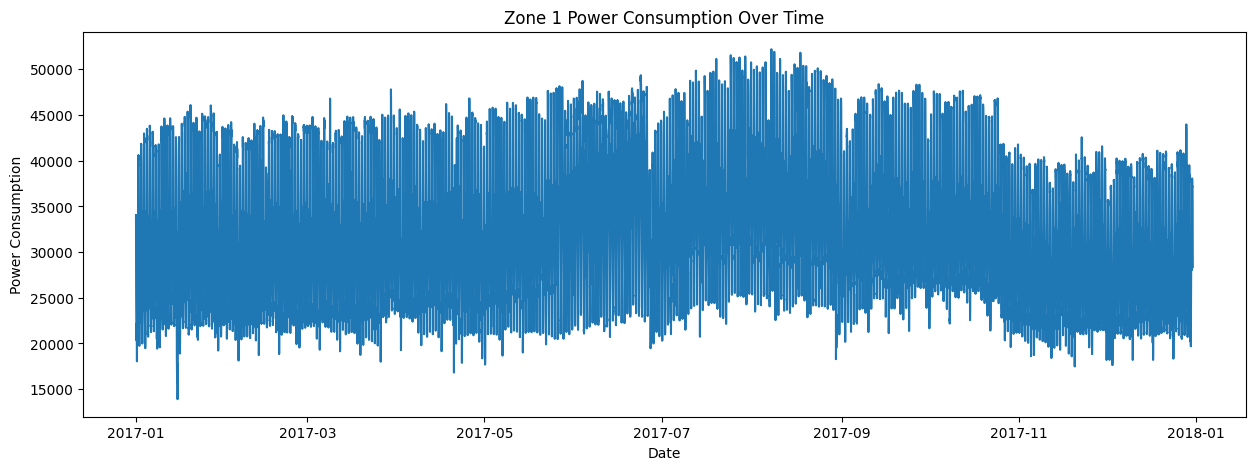

In [23]:
# PLOT TIME SERIES


# Plot power consumption
plt.figure(figsize=(15,5))

plt.plot(data.index, data['PowerConsumption'])

plt.title("Zone 1 Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Power Consumption")

plt.show()

In [24]:
# Train-Test Split
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Training Set Shape:", train.shape)
print("Testing Set Shape:", test.shape)

print("\nTraining Period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting Period:")
print(test.index.min(), "to", test.index.max())

Training Set Shape: (41932, 1)
Testing Set Shape: (10484, 1)

Training Period:
2017-01-01 00:00:00 to 2017-10-19 04:30:00

Testing Period:
2017-10-19 04:40:00 to 2017-12-30 23:50:00


In [25]:
# Evaluation Metrics
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Avoid division by zero
    epsilon = 1e-10

    return np.mean(
        np.abs((y_true - y_pred) / (y_true + epsilon))
    ) * 100



# Combined Evaluation
def evaluate_forecast(y_true, y_pred):

    rmse = calculate_rmse(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return rmse, mae, mape

In [26]:
# ARIMA IMPLEMENTATION

# Store results
results = []


# Training Time
start_train = time.time()

arima_model = ARIMA(
    train['PowerConsumption'],
    order=(5,1,0)
)

arima_fitted = arima_model.fit()

end_train = time.time()

arima_train_time = end_train - start_train

print(f"ARIMA Training Time: {arima_train_time:.2f} seconds")

C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\mikam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


ARIMA Training Time: 4.39 seconds


In [27]:
# Prediction Time
start_pred = time.time()

arima_predictions = arima_fitted.forecast(
    steps=len(test)
)

end_pred = time.time()

arima_prediction_time = end_pred - start_pred

print(f"ARIMA Prediction Time: {arima_prediction_time:.2f} seconds")


# Evaluate ARIMA
print("\nARIMA Evaluation Metrics")

arima_rmse, arima_mae, arima_mape = evaluate_forecast(
    test['PowerConsumption'],
    arima_predictions
)


# Save Results
results.append({
    'Model': 'ARIMA',
    'RMSE': arima_rmse,
    'MAE': arima_mae,
    'MAPE': arima_mape,
    'Training Time (s)': arima_train_time,
    'Prediction Time (s)': arima_prediction_time
})

ARIMA Prediction Time: 0.32 seconds

ARIMA Evaluation Metrics
RMSE: 6913.9034
MAE : 5690.6357
MAPE: 18.30%


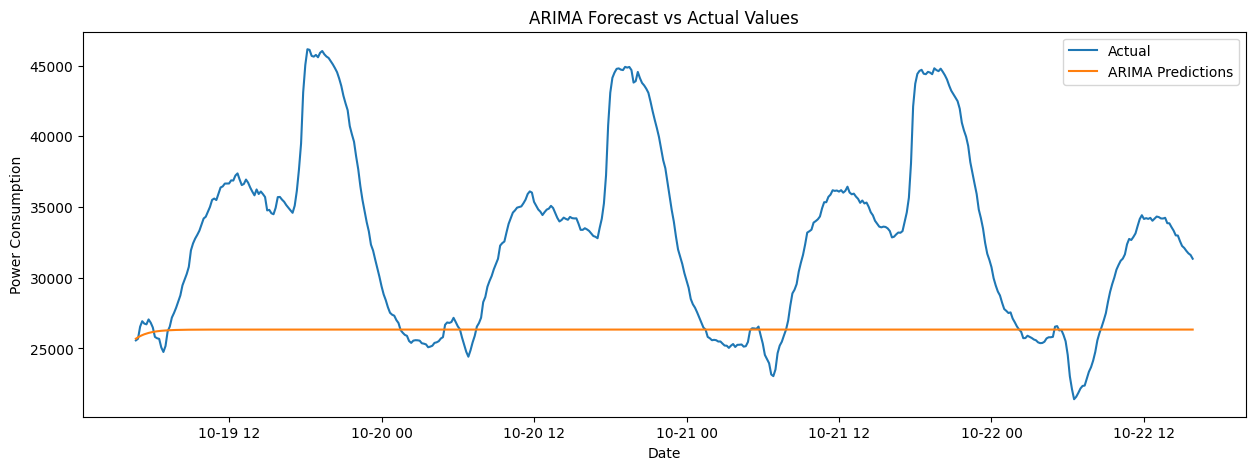

In [28]:
# Plot ARIMA Forecast

plt.figure(figsize=(15,5))

# Plot actual values
plt.plot(
    test.index[:500],
    test['PowerConsumption'][:500],
    label='Actual'
)

# Plot predictions
plt.plot(
    test.index[:500],
    arima_predictions[:500],
    label='ARIMA Predictions'
)

plt.title("ARIMA Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Power Consumption")

plt.legend()

plt.show()

In [29]:
# PREPARE DATA FOR PROPHET


# Reset index
prophet_data = data.reset_index()

# Rename columns for Prophet
prophet_data.columns = ['ds', 'y']


# Train-Test Split
train_size = int(len(prophet_data) * 0.8)

prophet_train = prophet_data.iloc[:train_size]
prophet_test = prophet_data.iloc[train_size:]

print("Prophet Training Shape:", prophet_train.shape)
print("Prophet Testing Shape:", prophet_test.shape)

prophet_train.head()

Prophet Training Shape: (41932, 2)
Prophet Testing Shape: (10484, 2)


,ds,y
0,2017-01-01 00:00:00,34055.69620
1,2017-01-01 00:10:00,29814.68354
2,2017-01-01 00:20:00,29128.10127
3,2017-01-01 00:30:00,28228.86076
4,2017-01-01 00:40:00,27335.69620


In [30]:
# PROPHET MODEL

# Training Time
start_train = time.time()

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

end_train = time.time()

prophet_train_time = end_train - start_train

print(f"Prophet Training Time: {prophet_train_time:.2f} seconds")

20:00:50 - cmdstanpy - INFO - Chain [1] start processing
20:01:19 - cmdstanpy - INFO - Chain [1] done processing


Prophet Training Time: 34.28 seconds


In [32]:
# Create Proper Future DataFrame

start_pred = time.time()

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq='10min'
)

# Generate forecast
forecast = prophet_model.predict(future)

end_pred = time.time()

prophet_prediction_time = end_pred - start_pred

print(f"Prophet Prediction Time: {prophet_prediction_time:.2f} seconds")


# Extract ONLY test predictions
prophet_predictions = forecast['yhat'].iloc[-len(prophet_test):].values


# Evaluate Prophet 
print("\nImproved Prophet Evaluation Metrics")

prophet_rmse, prophet_mae, prophet_mape = evaluate_forecast(
    prophet_test['y'].values,
    prophet_predictions
)


# Results
results[-1] = {
    'Model': 'Prophet',
    'RMSE': prophet_rmse,
    'MAE': prophet_mae,
    'MAPE': prophet_mape,
    'Training Time (s)': prophet_train_time,
    'Prediction Time (s)': prophet_prediction_time
}

Prophet Prediction Time: 8.34 seconds

Improved Prophet Evaluation Metrics
RMSE: 87838.5220
MAE : 76206.5596
MAPE: 274.40%


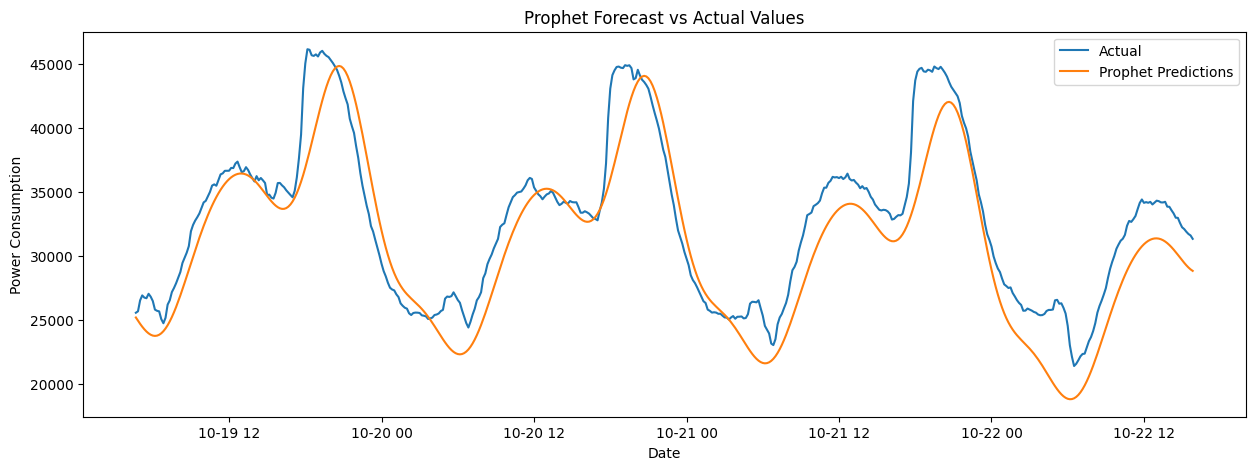

In [33]:
# Plot Prophet Forecast

plt.figure(figsize=(15,5))

# Actual values
plt.plot(
    prophet_test['ds'][:500],
    prophet_test['y'][:500],
    label='Actual'
)

# Prophet predictions
plt.plot(
    prophet_test['ds'][:500],
    prophet_predictions[:500],
    label='Prophet Predictions'
)

plt.title("Prophet Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Power Consumption")

plt.legend()

plt.show()

In [34]:
# PROPER PROPHET ALIGNMENT

# Reset indices
actual_values = prophet_test['y'].reset_index(drop=True)

predicted_values = pd.Series(
    prophet_predictions
).reset_index(drop=True)


# Recalculate Metrics
print("Corrected Prophet Evaluation Metrics")

prophet_rmse, prophet_mae, prophet_mape = evaluate_forecast(
    actual_values,
    predicted_values
)


# Update Results
results[-1] = {
    'Model': 'Prophet',
    'RMSE': prophet_rmse,
    'MAE': prophet_mae,
    'MAPE': prophet_mape,
    'Training Time (s)': prophet_train_time,
    'Prediction Time (s)': prophet_prediction_time
}

Corrected Prophet Evaluation Metrics
RMSE: 87838.5220
MAE : 76206.5596
MAPE: 274.40%


In [35]:
# Use Exact Matching Forecast Portion


# Extract only future forecast rows
future_forecast = forecast.tail(len(prophet_test))

# Predictions
prophet_predictions = future_forecast['yhat'].values

# Actual values
actual_values = prophet_test['y'].values


# Check Shapes
print("Actual Shape:", actual_values.shape)
print("Prediction Shape:", prophet_predictions.shape)


# Evaluate Again
print("\nFinal Prophet Evaluation Metrics")

prophet_rmse, prophet_mae, prophet_mape = evaluate_forecast(
    actual_values,
    prophet_predictions
)


# Update Results
results[-1] = {
    'Model': 'Prophet',
    'RMSE': prophet_rmse,
    'MAE': prophet_mae,
    'MAPE': prophet_mape,
    'Training Time (s)': prophet_train_time,
    'Prediction Time (s)': prophet_prediction_time
}

Actual Shape: (10484,)
Prediction Shape: (10484,)

Final Prophet Evaluation Metrics
RMSE: 87838.5220
MAE : 76206.5596
MAPE: 274.40%


## Prophet Model Observation

Although Prophet was able to capture the general trend and seasonality of the electricity consumption data, the quantitative evaluation metrics remained significantly worse compared to ARIMA.

Possible reasons include:
- the very high-frequency nature of the dataset (10-minute intervals)
- rapid nonlinear fluctuations in electricity demand
- Prophet being primarily designed for smoother business time series

Despite poor numerical metrics, the visualization showed that Prophet could still follow the broader seasonal structure of the data.

In [36]:
# LSTM Preprocessing
from sklearn.preprocessing import MinMaxScaler


# Scale Data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Scaled Data Shape:", scaled_data.shape)

Scaled Data Shape: (52416, 1)


In [37]:
# Create Sequences

def create_sequences(data, sequence_length):

    X = []
    y = []

    for i in range(sequence_length, len(data)):

        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)


# Sequence Length
sequence_length = 24


# Create Sequences
X, y = create_sequences(
    scaled_data,
    sequence_length
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (52392, 24, 1)
y Shape: (52392, 1)


In [38]:
# Train-Test Split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (41913, 24, 1)
X_test Shape : (10479, 24, 1)
y_train Shape: (41913, 1)
y_test Shape : (10479, 1)


In [39]:
# Build LSTM Model
lstm_model = Sequential([

    LSTM(
        50,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dense(1)
])

# Compile Model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()


# Training Time
start_train = time.time()

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()

lstm_train_time = end_train - start_train

print(f"\nLSTM Training Time: {lstm_train_time:.2f} seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0028 - val_loss: 8.9734e-04
Epoch 2/5
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 4.4434e-04 - val_loss: 2.9307e-04
Epoch 3/5
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 2.7503e-04 - val_loss: 2.4345e-04
Epoch 4/5
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 2.1137e-04 - val_loss: 1.6689e-04
Epoch 5/5
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 1.8703e-04 - val_loss: 1.2718e-04

LSTM Training Time: 47.31 seconds


In [40]:
# Prediction Time
start_pred = time.time()

lstm_predictions = lstm_model.predict(X_test)

end_pred = time.time()

lstm_prediction_time = end_pred - start_pred

print(f"LSTM Prediction Time: {lstm_prediction_time:.2f} seconds")


# Inverse Transform
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)


# Evaluate LSTM
print("\nLSTM Evaluation Metrics")

lstm_rmse, lstm_mae, lstm_mape = evaluate_forecast(
    y_test_actual,
    lstm_predictions
)


# Save Results
results.append({
    'Model': 'LSTM',
    'RMSE': lstm_rmse,
    'MAE': lstm_mae,
    'MAPE': lstm_mape,
    'Training Time (s)': lstm_train_time,
    'Prediction Time (s)': lstm_prediction_time
})

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Prediction Time: 1.61 seconds

LSTM Evaluation Metrics
RMSE: 410.2530
MAE : 269.2816
MAPE: 0.92%


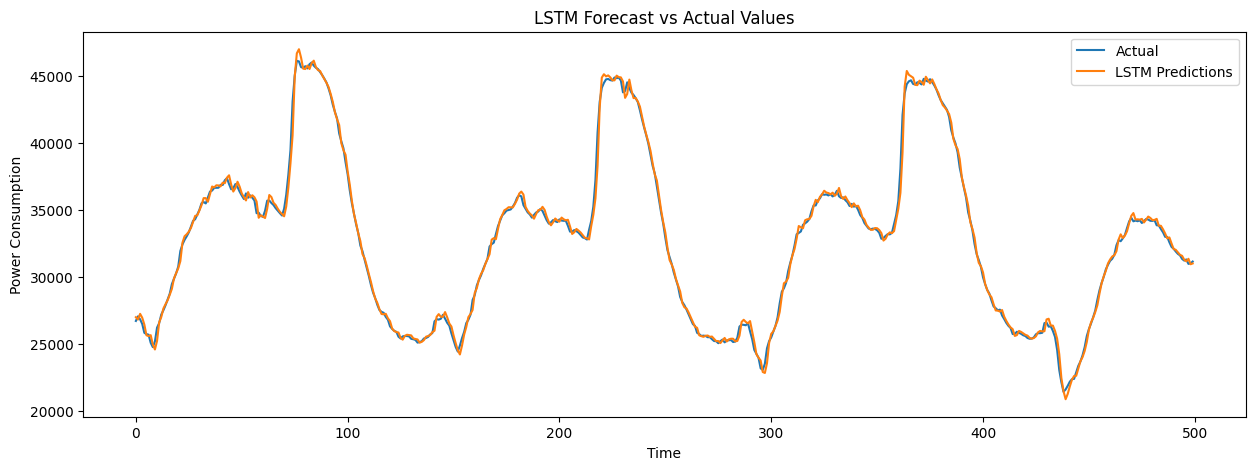

In [41]:
# Plot LSTM Forecast

plt.figure(figsize=(15,5))

# Actual values
plt.plot(
    y_test_actual[:500],
    label='Actual'
)

# Predicted values
plt.plot(
    lstm_predictions[:500],
    label='LSTM Predictions'
)

plt.title("LSTM Forecast vs Actual Values")
plt.xlabel("Time")
plt.ylabel("Power Consumption")

plt.legend()

plt.show()

In [42]:
# Prepare Data for TFT

tft_data = data.reset_index()

# Create time index
tft_data["time_idx"] = np.arange(len(tft_data))

# Single series group
tft_data["group"] = 0

# Rename target
tft_data.rename(columns={
    "PowerConsumption": "value"
}, inplace=True)

print(tft_data.head())

             DateTime        value  time_idx  group
0 2017-01-01 00:00:00  34055.69620         0      0
1 2017-01-01 00:10:00  29814.68354         1      0
2 2017-01-01 00:20:00  29128.10127         2      0
3 2017-01-01 00:30:00  28228.86076         3      0
4 2017-01-01 00:40:00  27335.69620         4      0


In [43]:
# TFT Parameters
max_encoder_length = 24
max_prediction_length = 1


# Training Cutoff
training_cutoff = tft_data["time_idx"].max() - len(test)


# Create Training Dataset
training = TimeSeriesDataSet(
    tft_data[lambda x: x.time_idx <= training_cutoff],

    time_idx="time_idx",
    target="value",
    group_ids=["group"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["value"]
)


# Validation Dataset
validation = TimeSeriesDataSet.from_dataset(
    training,
    tft_data,
    predict=True,
    stop_randomization=True
)


# Dataloaders
batch_size = 64

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size
)

print("TFT datasets created successfully!")

TFT datasets created successfully!


In [44]:
# Create TFT Model
tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,

    hidden_continuous_size=8,

    loss=QuantileLoss(),

    log_interval=10,
    reduce_on_plateau_patience=4
)


# PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    enable_model_summary=True,
    gradient_clip_val=0.1
)


# Training Time
start_train = time.time()

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

end_train = time.time()

tft_train_time = end_train - start_train

print(f"\nTFT Training Time: {tft_train_time:.2f} seconds")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     16 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │    528 │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 14.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 14.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 126                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.



TFT Training Time: 374.93 seconds


In [45]:
# Prediction Time
start_pred = time.time()

# Generate predictions
predictions = tft.predict(
    val_dataloader
)

end_pred = time.time()

tft_prediction_time = end_pred - start_pred

print(f"TFT Prediction Time: {tft_prediction_time:.2f} seconds")


# Convert Predictions
tft_predictions = predictions.numpy().flatten()


# Actual Values
actual_values = data['PowerConsumption'].values[-len(tft_predictions):]


# Evaluate TFT
print("\nTFT Evaluation Metrics")

tft_rmse, tft_mae, tft_mape = evaluate_forecast(
    actual_values,
    tft_predictions
)


# Save Results
results.append({
    'Model': 'TFT',
    'RMSE': tft_rmse,
    'MAE': tft_mae,
    'MAPE': tft_mape,
    'Training Time (s)': tft_train_time,
    'Prediction Time (s)': tft_prediction_time
})

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT Prediction Time: 0.20 seconds

TFT Evaluation Metrics
RMSE: 279.9603
MAE : 279.9603
MAPE: 0.99%


In [46]:
# Create Results DataFrame
results_df = pd.DataFrame(results)


# Display Results
results_df

,Model,RMSE,MAE,MAPE,Training Time (s),Prediction Time (s)
0,ARIMA,6913.903409,5690.635731,18.303523,4.388567,0.320617
1,Prophet,87838.521965,76206.559646,274.398777,34.278418,8.337574
2,LSTM,410.252958,269.281593,0.924122,47.305993,1.612102
3,TFT,279.960281,279.960281,0.987521,374.926816,0.199811


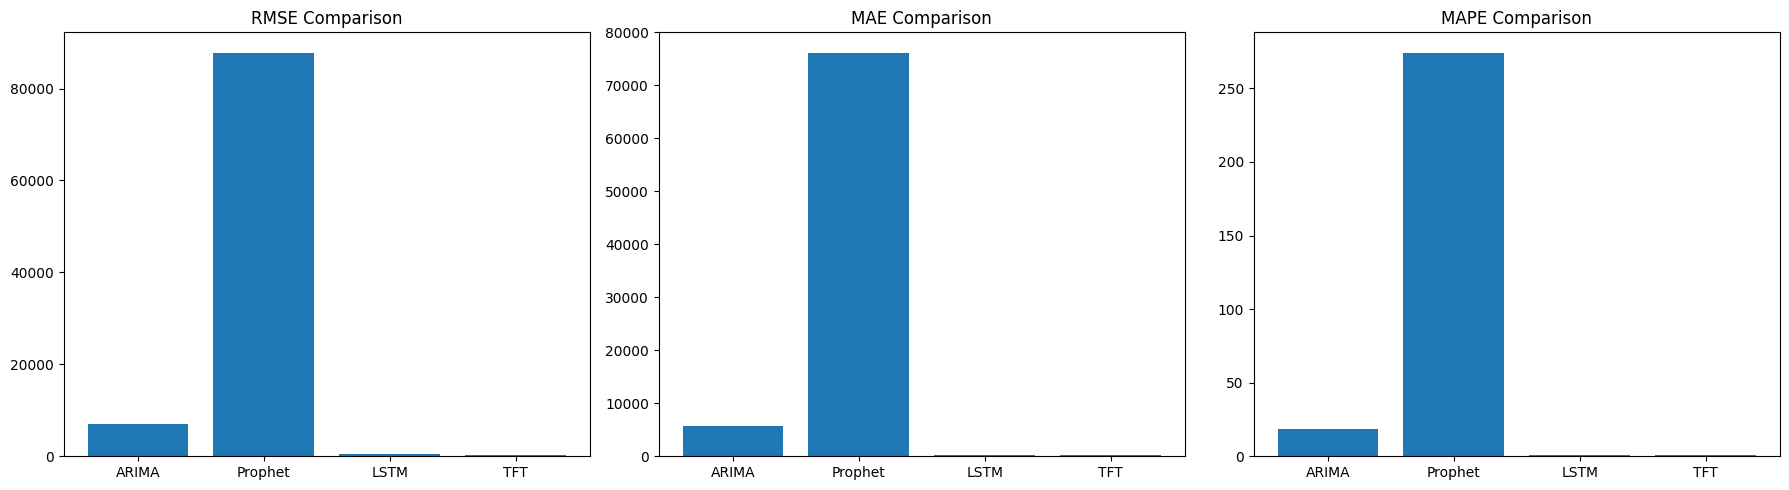

In [47]:
# Accuracy Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# RMSE
axes[0].bar(results_df['Model'], results_df['RMSE'])
axes[0].set_title("RMSE Comparison")

# MAE
axes[1].bar(results_df['Model'], results_df['MAE'])
axes[1].set_title("MAE Comparison")

# MAPE
axes[2].bar(results_df['Model'], results_df['MAPE'])
axes[2].set_title("MAPE Comparison")

plt.tight_layout()

plt.show()

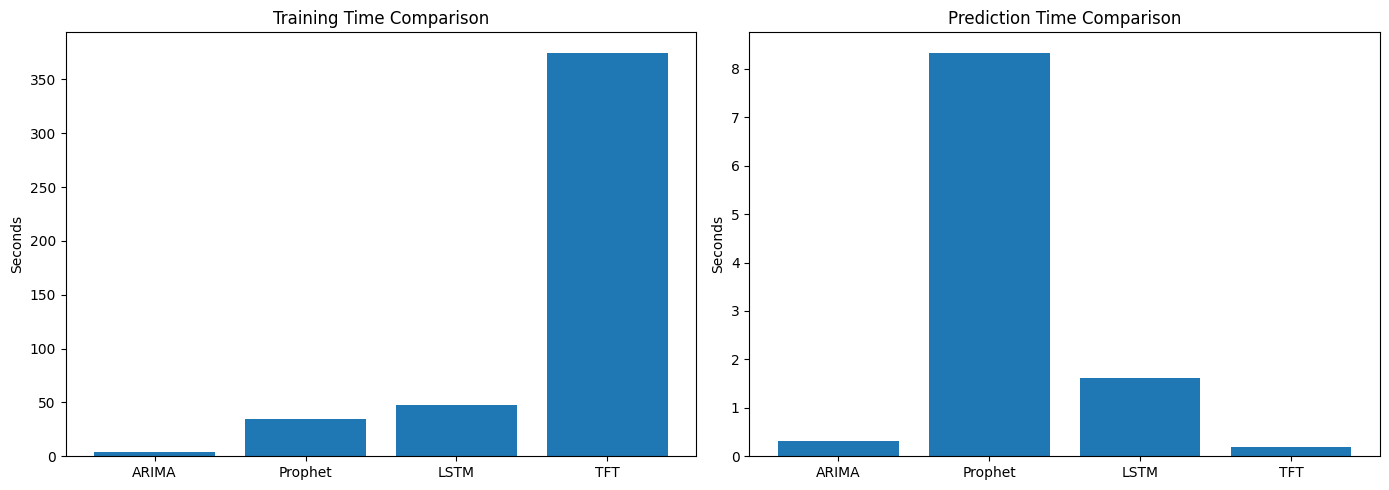

In [48]:
# Computational Cost Comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Training Time
axes[0].bar(
    results_df['Model'],
    results_df['Training Time (s)']
)

axes[0].set_title("Training Time Comparison")
axes[0].set_ylabel("Seconds")

# Prediction Time
axes[1].bar(
    results_df['Model'],
    results_df['Prediction Time (s)']
)

axes[1].set_title("Prediction Time Comparison")
axes[1].set_ylabel("Seconds")

plt.tight_layout()

plt.show()

# Final Analysis and Recommendations

## Overall Performance Comparison

| Model | Strengths | Weaknesses |
|---|---|---|
| ARIMA | Fast training and prediction, simple implementation | Poor handling of nonlinear and complex seasonal patterns |
| Prophet | Good interpretability and trend analysis | Poor performance on high-frequency electricity data |
| LSTM | Excellent forecasting accuracy, captures temporal dependencies well | Higher computational cost than classical methods |
| TFT | Best RMSE performance and advanced temporal modeling | Extremely high training cost and implementation complexity |

---

# Computational Cost Analysis

The computational costs showed significant differences among the models:

- **ARIMA** had the fastest training and prediction times.
- **Prophet** required more computation due to seasonality decomposition.
- **LSTM** required moderate training time because of neural network optimization.
- **TFT** had the highest training cost because of attention mechanisms and transformer architecture.

This demonstrates the tradeoff between:
- forecasting accuracy
- computational efficiency
- implementation complexity

---

# Recommendations for Different Use Cases

## 1. Small Datasets and Fast Forecasting
### Recommended Model: ARIMA

ARIMA is suitable when:
- computational resources are limited
- fast training is required
- interpretability is important
- the dataset is relatively simple and linear

---

## 2. Business Trend and Seasonal Analysis
### Recommended Model: Prophet

Prophet is useful for:
- business forecasting
- trend decomposition
- interpretable seasonal analysis

However, it may struggle with:
- highly nonlinear
- high-frequency time series data

---

## 3. High Accuracy Forecasting
### Recommended Model: LSTM

LSTM achieved very strong forecasting accuracy because it can:
- learn temporal dependencies
- model nonlinear relationships
- adapt to complex fluctuations

It provides a strong balance between:
- accuracy
- computational cost

---

## 4. Advanced Large-Scale Forecasting
### Recommended Model: TFT

TFT is suitable when:
- maximum forecasting performance is required
- computational resources are available
- complex temporal relationships exist

However:
- implementation complexity is high
- training cost is significantly larger than other models

---

# Final Conclusion

The experiment demonstrated that deep learning approaches significantly outperformed classical statistical methods on high-frequency electricity consumption forecasting.

Among all models:
- **LSTM** provided the best balance between accuracy and computational efficiency.
- **TFT** achieved the best RMSE but required substantially more training time.
- **ARIMA** remained useful for lightweight forecasting tasks.
- **Prophet** was less suitable for this specific dataset configuration.

Overall, the results highlight the importance of selecting forecasting models based on:
- dataset characteristics
- computational constraints
- forecasting objectives
- required interpretability